In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path

# DATA 디렉토리를 sys.path에 추가
data_path = Path(r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA")
sys.path.insert(0, str(data_path))

from stock_forecast.DATA.stock_invest_function import get_db_host
from sqlalchemy import create_engine


def get_db_info():
    """DB 연결 정보 반환"""
    return {
        "host": get_db_host(),
        "port": 3307,
        "user": "stox7412",
        "password": "Apt106503!~",
        "database": "investar",
    }


def get_engine(db_info):
    """SQLAlchemy 엔진 생성"""
    url = (
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}"
        f"@{db_info['host']}:{db_info['port']}/{db_info['database']}?charset=utf8mb4"
    )
    return create_engine(url)


def get_unique_items(engine, table_name: str) -> list:
    """
    테이블에서 유니크한 item 리스트만 추출
    """
    query = f"SELECT DISTINCT item FROM {table_name} ORDER BY item"

    try:
        df = pd.read_sql(query, engine)
        unique_items = df['item'].tolist()
        print(f"[{table_name}] 총 {len(unique_items)}개의 유니크 항목 발견")
        return unique_items

    except Exception as e:
        print(f"[ERROR] {table_name} 조회 중 오류: {e}")
        return []


def main():
    """메인 실행 함수"""
    # DB 연결
    db_info = get_db_info()
    engine = get_engine(db_info)

    # BS 항목 확인
    bs_items = get_unique_items(engine, "US_BS_from_FMP")
    print("US_BS_from_FMP - 유니크 항목 리스트")
    print("-" * 80)
    for i, item in enumerate(bs_items, 1):
        print(f"{i:3d}. {item}")

    # IS 항목 확인
    print("\n")
    is_items = get_unique_items(engine, "US_IS_from_FMP")
    print("US_IS_from_FMP - 유니크 항목 리스트")
    print("-" * 80)
    for i, item in enumerate(is_items, 1):
        print(f"{i:3d}. {item}")

    # 결과 반환
    return {
        'bs_items': bs_items,
        'is_items': is_items
    }


if __name__ == "__main__":
    items = main()
    bs_items = items['bs_items']
    is_items = items['is_items']

C:\Users\Hoyoung_Park\PyCharmMiscProject\.venv1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[US_BS_from_FMP] 총 18개의 유니크 항목 발견
US_BS_from_FMP - 유니크 항목 리스트
--------------------------------------------------------------------------------
  1. ao
  2. ap
  3. at
  4. be
  5. ca
  6. cash
  7. debt
  8. debtlt
  9. debtst
 10. intan
 11. invt
 12. ivao
 13. lo
 14. lt
 15. ppen
 16. pstk
 17. rec
 18. txp


[US_IS_from_FMP] 총 21개의 유니크 항목 발견
US_IS_from_FMP - 유니크 항목 리스트
--------------------------------------------------------------------------------
  1. cogs
  2. dp
  3. ebitda
  4. eps
  5. epsdi
  6. gp
  7. idit
  8. ni
  9. nir
 10. opir
 11. opiti
 12. pi
 13. pir
 14. sale
 15. shrout
 16. shroutdi
 17. txt
 18. xint
 19. xopr
 20. xrd
 21. xsga



FMP 재무 항목 설명

[Balance Sheet - 대차대조표 항목]
--------------------------------------------------------------------------------
 1. ao         : Assets - Other (기타 자산)
 2. ap         : Accounts Payable (매입채무)
 3. at         : Assets - Total (총자산)
 4. be         : Book Equity (장부가치 자본, 보통주 자본)
 5. ca         : Current Assets (유동자산)
 6. cash       : Cash and Short-Term Investments (현금 및 단기투자)
 7. debt       : Debt - Total (총부채)
 8. debtlt     : Long-Term Debt (장기부채)
 9. debtst     : Short-Term Debt (단기부채)
10. intan      : Intangible Assets (무형자산)
11. invt       : Inventories (재고자산)
12. ivao       : Investment and Advances - Other (기타 투자 및 선급금)
13. lo         : Liabilities - Other (기타 부채)
14. lt         : Liabilities - Total (총부채)
15. ppen       : Property, Plant and Equipment - Net (유형자산 순액)
16. pstk       : Preferred Stock (우선주)
17. rec        : Receivables (매출채권)
18. txp        : Income Taxes Payable (미지급 법인세)

[Income Statement - 손익계산서 항목]
--------------------------------------------------

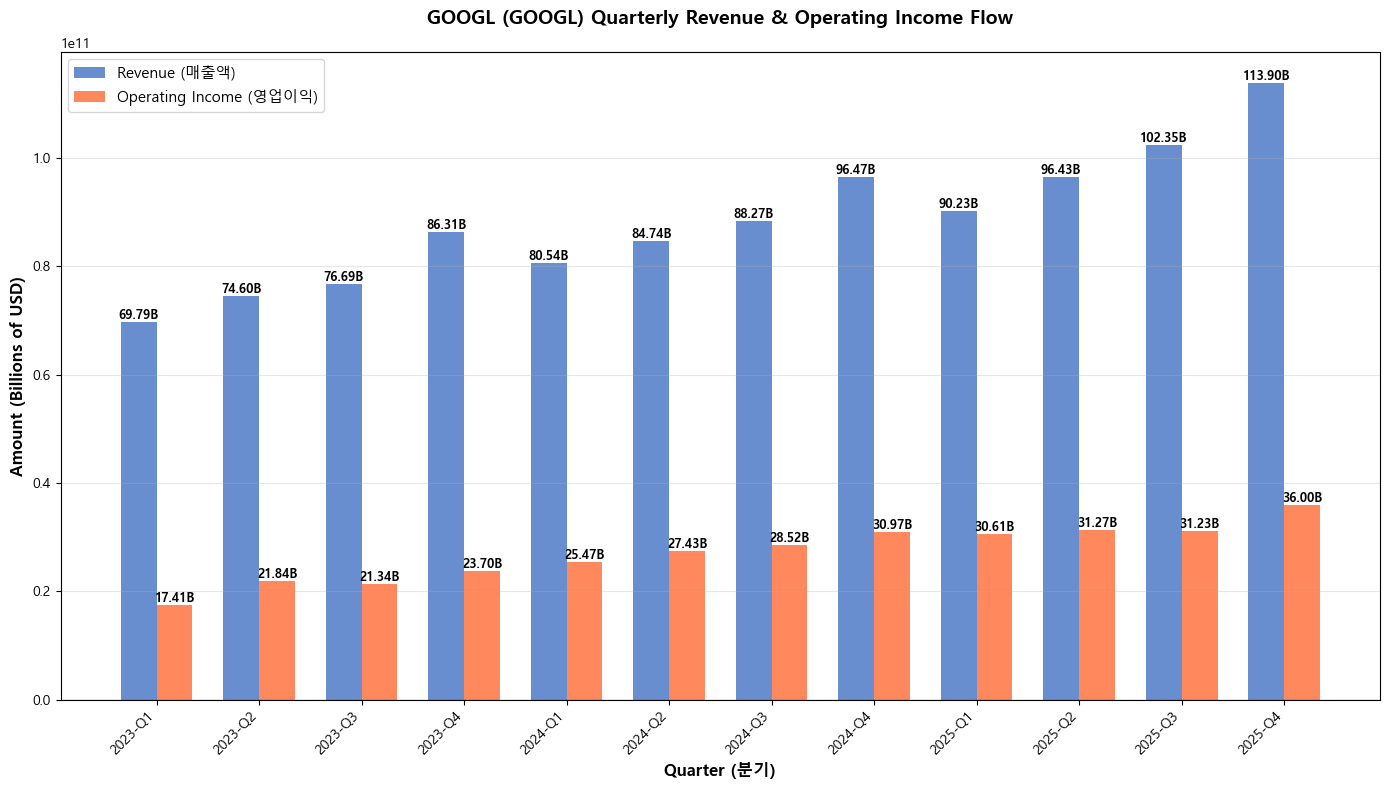



2. 회귀분석 차트 생성 중 (최근 20분기)...

회귀분석 데이터 확인:
요청한 분기 수: 20
추출된 데이터: 12개

데이터 미리보기:
         date year_quarter       revenue  operating_income
2  2023-03-31      2023-Q1  6.978700e+10      1.741500e+10
5  2023-06-30      2023-Q2  7.460400e+10      2.183800e+10
8  2023-09-30      2023-Q3  7.669300e+10      2.134300e+10
11 2023-12-31      2023-Q4  8.631000e+10      2.369700e+10
14 2024-03-31      2024-Q1  8.053900e+10      2.547200e+10
17 2024-06-30      2024-Q2  8.474200e+10      2.742500e+10
20 2024-09-30      2024-Q3  8.826800e+10      2.852100e+10
23 2024-12-31      2024-Q4  9.646900e+10      3.097200e+10
26 2025-03-31      2025-Q1  9.023400e+10      3.060600e+10
29 2025-06-30      2025-Q2  9.642800e+10      3.127100e+10
32 2025-09-30      2025-Q3  1.023460e+11      3.122800e+10
35 2025-12-31      2025-Q4  1.138960e+11      3.600200e+10

결측값/0값 제거 후: 12개
차트 저장 완료: GOOGL_regression_analysis.png


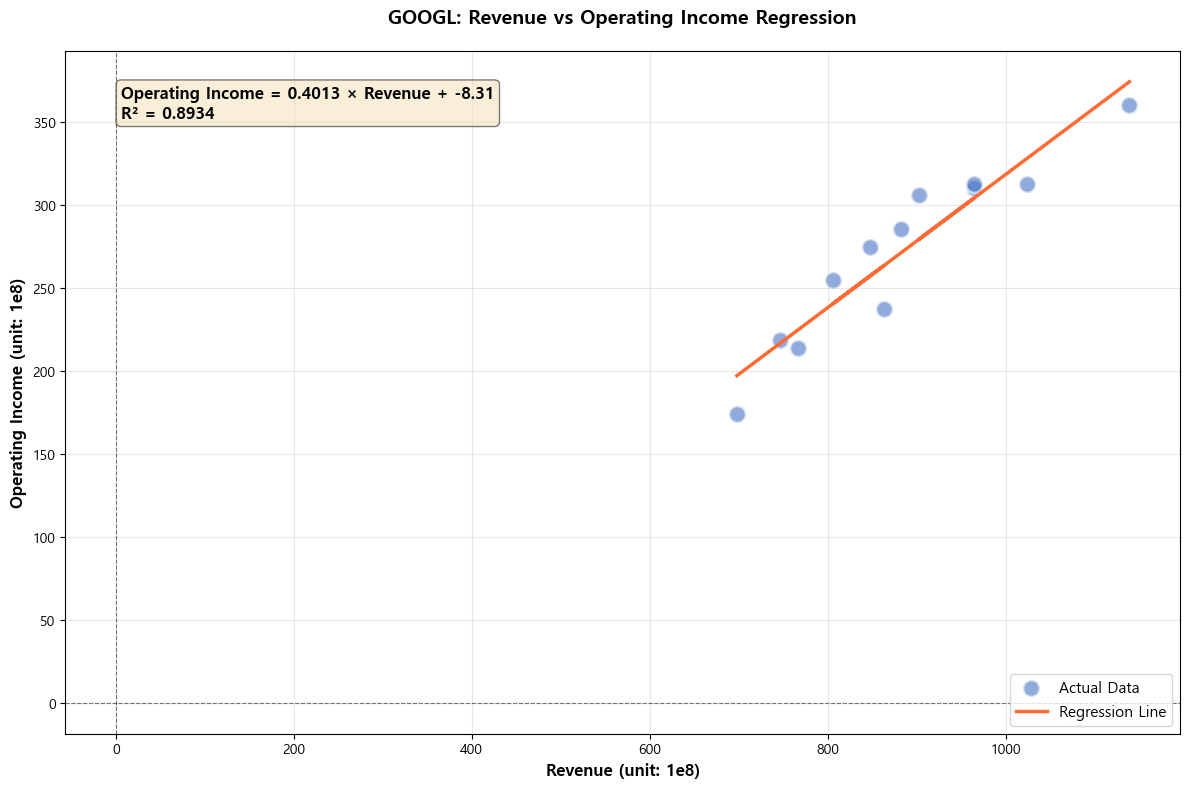


회귀분석 결과
회귀식: Operating Income = 0.4013 × Revenue + -8.31B
R² (결정계수): 0.8934
사용 데이터 개수: 12개 (요청: 20분기)


In [3]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path
from datetime import datetime
from sklearn.linear_model import LinearRegression

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# DATA 디렉토리를 sys.path에 추가
data_path = Path(r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA")
sys.path.insert(0, str(data_path))

from stock_forecast.DATA.stock_invest_function import get_db_host
from sqlalchemy import create_engine


# ===== 1. FMP 재무 항목 설명 =====

FMP_ITEM_DESCRIPTIONS = {
    # Balance Sheet (BS) 항목
    'ao': 'Assets - Other (기타 자산)',
    'ap': 'Accounts Payable (매입채무)',
    'at': 'Assets - Total (총자산)',
    'be': "Book Equity (장부가치 자본, 보통주 자본)",
    'ca': 'Current Assets (유동자산)',
    'cash': 'Cash and Short-Term Investments (현금 및 단기투자)',
    'debt': 'Debt - Total (총부채)',
    'debtlt': 'Long-Term Debt (장기부채)',
    'debtst': 'Short-Term Debt (단기부채)',
    'intan': 'Intangible Assets (무형자산)',
    'invt': 'Inventories (재고자산)',
    'ivao': 'Investment and Advances - Other (기타 투자 및 선급금)',
    'lo': 'Liabilities - Other (기타 부채)',
    'lt': 'Liabilities - Total (총부채)',
    'ppen': 'Property, Plant and Equipment - Net (유형자산 순액)',
    'pstk': 'Preferred Stock (우선주)',
    'rec': 'Receivables (매출채권)',
    'txp': 'Income Taxes Payable (미지급 법인세)',

    # Income Statement (IS) 항목
    'cogs': 'Cost of Goods Sold (매출원가)',
    'dp': 'Depreciation and Amortization (감가상각비)',
    'ebitda': 'EBITDA (이자, 세금, 감가상각 전 이익)',
    'eps': 'Earnings Per Share (Basic) (기본 주당순이익)',
    'epsdi': 'Earnings Per Share (Diluted) (희석 주당순이익)',
    'gp': 'Gross Profit (매출총이익)',
    'idit': 'Deferred Taxes - Income Statement Impact (이연법인세)',
    'ni': 'Net Income (순이익)',
    'nir': 'Nonoperating Income (Expense) (영업외손익)',
    'opir': 'Operating Income (영업이익)',  # 핵심 항목
    'opiti': 'Operating Income After Depreciation (감가상각 후 영업이익)',
    'pi': 'Pretax Income (세전이익)',
    'pir': 'Pretax Income (세전이익)',
    'sale': 'Sales/Revenue (매출액)',  # 핵심 항목
    'shrout': 'Common Shares Outstanding (보통주 발행주식수)',
    'shroutdi': 'Common Shares Used to Calculate EPS - Diluted (희석 EPS 계산용 주식수)',
    'txt': 'Income Taxes - Total (총법인세)',
    'xint': 'Interest Expense (이자비용)',
    'xopr': 'Operating Expenses - Total (총영업비용)',
    'xrd': 'Research and Development Expense (연구개발비)',
    'xsga': 'Selling, General and Administrative Expense (판매관리비)',
}


def get_db_info():
    """DB 연결 정보 반환"""
    return {
        "host": get_db_host(),
        "port": 3307,
        "user": "stox7412",
        "password": "Apt106503!~",
        "database": "investar",
    }


def get_engine(db_info):
    """SQLAlchemy 엔진 생성"""
    url = (
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}"
        f"@{db_info['host']}:{db_info['port']}/{db_info['database']}?charset=utf8mb4"
    )
    return create_engine(url)


def print_item_descriptions():
    """재무 항목 설명 출력"""
    print("\n" + "="*80)
    print("FMP 재무 항목 설명")
    print("="*80)

    print("\n[Balance Sheet - 대차대조표 항목]")
    print("-"*80)
    bs_items = ['ao', 'ap', 'at', 'be', 'ca', 'cash', 'debt', 'debtlt',
                'debtst', 'intan', 'invt', 'ivao', 'lo', 'lt', 'ppen',
                'pstk', 'rec', 'txp']
    for i, item in enumerate(bs_items, 1):
        print(f"{i:2d}. {item:10s} : {FMP_ITEM_DESCRIPTIONS[item]}")

    print("\n[Income Statement - 손익계산서 항목]")
    print("-"*80)
    is_items = ['cogs', 'dp', 'ebitda', 'eps', 'epsdi', 'gp', 'idit',
                'ni', 'nir', 'opir', 'opiti', 'pi', 'pir', 'sale',
                'shrout', 'shroutdi', 'txt', 'xint', 'xopr', 'xrd', 'xsga']
    for i, item in enumerate(is_items, 1):
        print(f"{i:2d}. {item:10s} : {FMP_ITEM_DESCRIPTIONS[item]}")

    print("\n" + "="*80)


def get_financial_data(engine, ticker, start_date=None, end_date=None,
                       revenue_item='sale', operating_income_item='opiti'):
    """
    특정 티커의 재무 데이터 조회 (분기별만)

    Parameters:
    -----------
    engine : sqlalchemy.engine.Engine
        DB 엔진
    ticker : str
        티커 심볼
    start_date : str, optional
        시작 날짜 (YYYY-MM-DD)
    end_date : str, optional
        종료 날짜 (YYYY-MM-DD)
    revenue_item : str
        매출 항목 (기본: 'sale')
    operating_income_item : str
        영업이익 항목 (기본: 'opiti' - Operating Income After Depreciation)
        다른 옵션: 'opir' (Operating Income Ratio - 비율), 'gp' (Gross Profit)

    Returns:
    --------
    pd.DataFrame
        매출액과 영업이익 데이터 (분기별)
    """
    # 날짜 필터 조건 (서브쿼리 내부에서 사용)
    date_filter = ""
    if start_date:
        date_filter += f" AND date >= '{start_date}'"
    if end_date:
        date_filter += f" AND date <= '{end_date}'"

    query = f"""
    SELECT
        base.date,
        base.ticker,
        COALESCE(is_sale.value, 0) as revenue,
        COALESCE(is_oi.value, 0) as operating_income
    FROM
        (SELECT DISTINCT date, ticker
         FROM US_IS_from_FMP
         WHERE ticker = '{ticker}'{date_filter}
        ) base
    LEFT JOIN
        (SELECT date, ticker, value
         FROM US_IS_from_FMP
         WHERE item = '{revenue_item}' AND ticker = '{ticker}'
        ) is_sale
        ON base.date = is_sale.date AND base.ticker = is_sale.ticker
    LEFT JOIN
        (SELECT date, ticker, value
         FROM US_IS_from_FMP
         WHERE item = '{operating_income_item}' AND ticker = '{ticker}'
        ) is_oi
        ON base.date = is_oi.date AND base.ticker = is_oi.ticker
    ORDER BY
        base.date
    """

    df = pd.read_sql(query, engine)

    if df.empty:
        return df

    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')

    # 0이 아닌 값이 있는 행만 유지
    df = df[(df['revenue'] != 0) | (df['operating_income'] != 0)].copy()

    # 연도와 분기 정보 추가
    df['year'] = df['date'].dt.year
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year_quarter'] = df['year'].astype(str) + '-Q' + df['quarter'].astype(str)

    # 분기 말일 데이터만 선택 (3월, 6월, 9월, 12월)
    # 각 분기의 마지막 달 데이터만 유지
    quarter_end_months = [3, 6, 9, 12]
    df_quarterly = df[df['month'].isin(quarter_end_months)].copy()

    # month 컬럼 제거
    df_quarterly = df_quarterly.drop(columns=['month'])

    print(f"전체 데이터: {len(df)}개 → 분기별 데이터: {len(df_quarterly)}개")
    print(f"사용 항목: revenue={revenue_item}, operating_income={operating_income_item}")

    return df_quarterly


def check_available_items(engine, ticker):
    """
    특정 티커의 사용 가능한 IS 항목 확인

    Parameters:
    -----------
    engine : sqlalchemy.engine.Engine
        DB 엔진
    ticker : str
        티커 심볼
    """
    query = f"""
    SELECT DISTINCT item
    FROM US_IS_from_FMP
    WHERE ticker = '{ticker}'
    ORDER BY item
    """

    df = pd.read_sql(query, engine)
    items = df['item'].tolist()

    print(f"\n{ticker}의 사용 가능한 IS 항목:")
    print("-" * 80)
    for i, item in enumerate(items, 1):
        desc = FMP_ITEM_DESCRIPTIONS.get(item, '설명 없음')
        print(f"{i:2d}. {item:10s} : {desc}")

    return items


def preview_item_values(engine, ticker, item, n=10):
    """
    특정 항목의 최근 값 미리보기

    Parameters:
    -----------
    engine : sqlalchemy.engine.Engine
        DB 엔진
    ticker : str
        티커 심볼
    item : str
        항목 코드
    n : int
        조회할 행 수
    """
    query = f"""
    SELECT date, value
    FROM US_IS_from_FMP
    WHERE ticker = '{ticker}' AND item = '{item}'
    ORDER BY date DESC
    LIMIT {n}
    """

    df = pd.read_sql(query, engine)
    df['date'] = pd.to_datetime(df['date'])

    print(f"\n{ticker}의 {item} 최근 {n}개 값:")
    print("-" * 80)
    print(df.to_string(index=False))

    return df


def plot_revenue_operating_income_bar(df, ticker, figsize=(14, 8), save_path=None):
    """
    매출액과 영업이익 분기별 막대 차트

    Parameters:
    -----------
    df : pd.DataFrame
        재무 데이터
    ticker : str
        티커 심볼
    figsize : tuple
        그래프 크기
    save_path : str, optional
        저장 경로
    """
    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(df))
    width = 0.35

    # 막대 그래프
    bars1 = ax.bar(x - width/2, df['revenue'], width,
                   label='Revenue (매출액)', color='#4472C4', alpha=0.8)
    bars2 = ax.bar(x + width/2, df['operating_income'], width,
                   label='Operating Income (영업이익)', color='#FF6B35', alpha=0.8)

    # 값 레이블
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if pd.notna(height) and height != 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height/1e9:.2f}B',
                       ha='center', va='bottom' if height > 0 else 'top',
                       fontsize=9, fontweight='bold')

    # 축 설정
    ax.set_xlabel('Quarter (분기)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Amount (Billions of USD)', fontsize=12, fontweight='bold')
    ax.set_title(f'{ticker} ({df["ticker"].iloc[0]}) Quarterly Revenue & Operating Income Flow',
                fontsize=14, fontweight='bold', pad=20)

    ax.set_xticks(x)
    ax.set_xticklabels(df['year_quarter'], rotation=45, ha='right')
    ax.legend(loc='upper left', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"차트 저장 완료: {save_path}")

    plt.show()


def plot_regression_analysis(df, ticker, n_periods=20, figsize=(12, 8), save_path=None):
    """
    매출액 vs 영업이익 회귀분석 차트

    Parameters:
    -----------
    df : pd.DataFrame
        재무 데이터
    ticker : str
        티커 심볼
    n_periods : int
        사용할 데이터 개수 (기본 20분기)
    figsize : tuple
        그래프 크기
    save_path : str, optional
        저장 경로
    """
    # 최근 n_periods 데이터만 사용
    df_recent = df.tail(n_periods).copy()

    print(f"\n회귀분석 데이터 확인:")
    print(f"요청한 분기 수: {n_periods}")
    print(f"추출된 데이터: {len(df_recent)}개")
    print(f"\n데이터 미리보기:")
    print(df_recent[['date', 'year_quarter', 'revenue', 'operating_income']])

    # 결측값 및 0값 제거
    df_clean = df_recent[
        (df_recent['revenue'].notna()) &
        (df_recent['operating_income'].notna()) &
        (df_recent['revenue'] != 0) &
        (df_recent['operating_income'] != 0)
    ].copy()

    print(f"\n결측값/0값 제거 후: {len(df_clean)}개")

    if len(df_clean) < 3:
        print(f"⚠ 회귀분석을 위한 데이터가 부족합니다. (최소 3개 필요, 현재 {len(df_clean)}개)")
        return

    # 회귀분석
    X = df_clean['revenue'].values.reshape(-1, 1)
    y = df_clean['operating_income'].values

    model = LinearRegression()
    model.fit(X, y)

    # 예측값
    y_pred = model.predict(X)

    # R² 계산
    r_squared = model.score(X, y)

    # 회귀식 계수
    slope = model.coef_[0]
    intercept = model.intercept_

    # 시각화
    fig, ax = plt.subplots(figsize=figsize)

    # 산점도
    ax.scatter(df_clean['revenue']/1e8, df_clean['operating_income']/1e8,
              s=150, alpha=0.6, color='#4472C4', edgecolors='white', linewidth=2,
              label='Actual Data')

    # 회귀선
    ax.plot(df_clean['revenue']/1e8, y_pred/1e8,
           color='#FF6B35', linewidth=2.5, label='Regression Line')

    # 회귀식과 R² 표시
    equation_text = f'Operating Income = {slope:.4f} × Revenue + {intercept/1e9:.2f}\nR² = {r_squared:.4f}'
    ax.text(0.05, 0.95, equation_text,
           transform=ax.transAxes, fontsize=12, fontweight='bold',
           verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # 축 설정
    ax.set_xlabel('Revenue (unit: 1e8)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Operating Income (unit: 1e8)', fontsize=12, fontweight='bold')
    ax.set_title(f'{ticker}: Revenue vs Operating Income Regression',
                fontsize=14, fontweight='bold', pad=20)

    ax.legend(loc='lower right', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"차트 저장 완료: {save_path}")

    plt.show()

    # 회귀분석 결과 출력
    print("\n" + "="*80)
    print("회귀분석 결과")
    print("="*80)
    print(f"회귀식: Operating Income = {slope:.4f} × Revenue + {intercept/1e9:.2f}B")
    print(f"R² (결정계수): {r_squared:.4f}")
    print(f"사용 데이터 개수: {len(df_clean)}개 (요청: {n_periods}분기)")
    print("="*80)


def main():
    """메인 실행 함수"""
    # 1. 재무 항목 설명 출력
    print_item_descriptions()

    # DB 연결
    db_info = get_db_info()
    engine = get_engine(db_info)

    # 2. 티커 및 기간 설정
    ticker = 'GOOGL'  # 예시: Palantir
    start_date = '2023-01-01'  # 시작 날짜 (조절 가능)
    end_date = None  # 종료 날짜 (None이면 최신까지)

    # 3. 사용 가능한 항목 확인
    print(f"\n{'='*80}")
    print(f"{ticker}의 재무 항목 확인")
    print(f"{'='*80}")
    available_items = check_available_items(engine, ticker)

    # 4. 영업이익 관련 항목 미리보기
    print("\n\n영업이익 관련 항목 값 미리보기:")
    if 'opir' in available_items:
        preview_item_values(engine, ticker, 'opir', n=5)
    if 'opiti' in available_items:
        preview_item_values(engine, ticker, 'opiti', n=5)
    if 'pi' in available_items:
        preview_item_values(engine, ticker, 'pi', n=5)

    # 5. 영업이익 항목 선택
    # opiti: Operating Income After Depreciation (감가상각 후 영업이익)
    # pi: Pretax Income (세전이익)
    operating_income_item = 'opiti'  # 또는 'pi'

    print(f"\n\n데이터 조회 중: {ticker} (기간: {start_date} ~ {'현재' if not end_date else end_date})")
    print(f"영업이익 항목: {operating_income_item}")

    # 6. 데이터 조회
    df = get_financial_data(engine, ticker, start_date, end_date,
                           operating_income_item=operating_income_item)

    if df.empty:
        print(f"⚠ {ticker}의 재무 데이터가 없습니다.")
        return

    print(f"✓ 데이터 조회 완료: {len(df)}개 분기")
    print(f"\n데이터 미리보기:")
    print(df[['date', 'year_quarter', 'revenue', 'operating_income']].tail(10))

    # 7. 분기별 막대 차트
    print("\n\n1. 분기별 매출액 & 영업이익 차트 생성 중...")
    plot_revenue_operating_income_bar(
        df,
        ticker,
        save_path=f'{ticker}_quarterly_flow.png'
    )

    # 8. 회귀분석 차트 (최근 20분기)
    print("\n\n2. 회귀분석 차트 생성 중 (최근 20분기)...")
    plot_regression_analysis(
        df,
        ticker,
        n_periods=20,
        save_path=f'{ticker}_regression_analysis.png'
    )


if __name__ == "__main__":
    main()